# Importing Libraries

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import mean_absolute_error, r2_score

# Importing Data

In [3]:
# Define the ticker symbol
ticker_symbol = 'HINDUNILVR.NS'  # Example: Hindustan Unilever Ltd.

# Set the start and end dates for the historical data
start_date = '2000-01-01'
end_date = '2024-03-03'

# Fetch historical data from Yahoo Finance
df = yf.download(ticker_symbol, start=start_date, end=end_date)

# Reset the index to make 'Date' a column
df.reset_index(inplace=True)

[*********************100%%**********************]  1 of 1 completed


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036 entries, 0 to 6035
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6036 non-null   datetime64[ns]
 1   Open       6036 non-null   float64       
 2   High       6036 non-null   float64       
 3   Low        6036 non-null   float64       
 4   Close      6036 non-null   float64       
 5   Adj Close  6036 non-null   float64       
 6   Volume     6036 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 330.2 KB


In [5]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
6031,2024-02-26,2391.100098,2406.550049,2380.000000,2404.250000,2404.250000,831596
6032,2024-02-27,2404.050049,2408.949951,2389.149902,2405.300049,2405.300049,1120424
6033,2024-02-28,2411.100098,2425.000000,2401.000000,2421.550049,2421.550049,629152
6034,2024-02-29,2425.000000,2428.800049,2397.250000,2412.300049,2412.300049,2848084
6035,2024-03-01,2416.949951,2438.800049,2404.000000,2409.699951,2409.699951,2326244


# Data Preprocessing

In [6]:
# Extract only the 'Close' prices for simplicity
dataset = df[['Close']].values

# Scale the data
sc = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = sc.fit_transform(dataset)

# Prepare the dataset
X_train, y_train = [], []
for i in range(60, len(dataset_scaled)):
    X_train.append(dataset_scaled[i-60:i, 0])
    y_train.append(dataset_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape the data for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Building the LSTM Model

In [7]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Training the model
model.fit(X_train, y_train, epochs=50, batch_size=32)

# Predicting the stock prices
inputs = dataset_scaled[len(dataset_scaled) - len(df):]
X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = model.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

Epoch 1/50
187/187 [==============================] - 16s 65ms/step - loss: 0.0045
Epoch 2/50
187/187 [==============================] - 13s 69ms/step - loss: 0.0022
Epoch 3/50
187/187 [==============================] - 14s 75ms/step - loss: 0.0019
Epoch 4/50
187/187 [==============================] - 13s 70ms/step - loss: 0.0016
Epoch 5/50
187/187 [==============================] - 13s 68ms/step - loss: 0.0015
Epoch 6/50
187/187 [==============================] - 13s 68ms/step - loss: 0.0014
Epoch 7/50
187/187 [==============================] - 13s 67ms/step - loss: 0.0015
Epoch 8/50
187/187 [==============================] - 13s 67ms/step - loss: 0.0013
Epoch 9/50
187/187 [==============================] - 12s 67ms/step - loss: 0.0012
Epoch 10/50
187/187 [==============================] - 12s 66ms/step - loss: 0.0012
Epoch 11/50
187/187 [==============================] - 12s 66ms/step - loss: 0.0013
Epoch 12/50
187/187 [==============================] - 12s 66ms/step - loss: 0.0012
E

In [8]:
# Extract actual close prices from DataFrame
actual_close_prices = df['Close'].values

# Calculate Mean Squared Error
mse = mean_squared_error(actual_close_prices[-len(predicted_stock_price):], predicted_stock_price)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse).round(2)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 30.88


In [9]:
# Calculate Mean Absolute Error
mae = mean_absolute_error(actual_close_prices[-len(predicted_stock_price):], predicted_stock_price)

print("Mean Absolute Error:", round(mae, 2))

Mean Absolute Error: 18.08


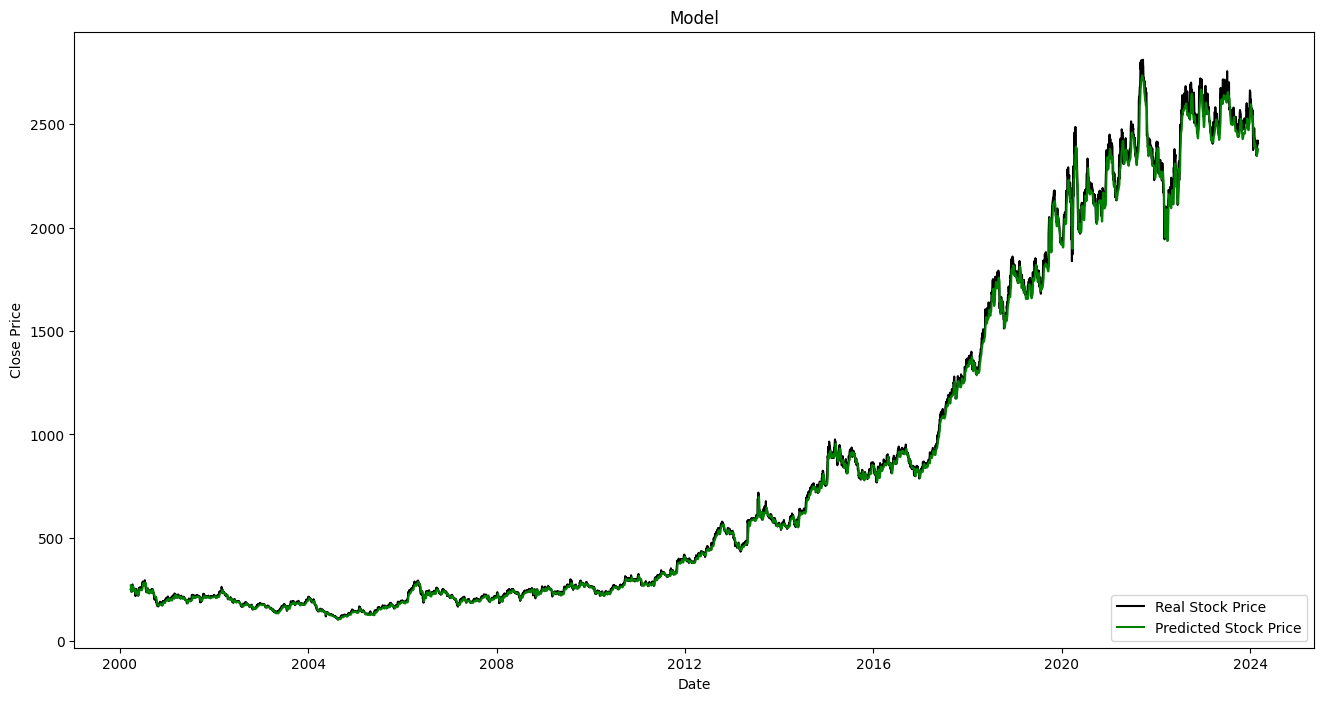

In [10]:
# Plot the results
plt.figure(figsize=(16, 8))
plt.title('Model')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.plot(df['Date'][-len(predicted_stock_price):], dataset[-len(predicted_stock_price):], color='black', label='Real Stock Price')
plt.plot(df['Date'][-len(predicted_stock_price):], predicted_stock_price, color='green', label='Predicted Stock Price')
plt.legend(loc='lower right')
plt.show()

1/1 [==============================] - 0s 24ms/step


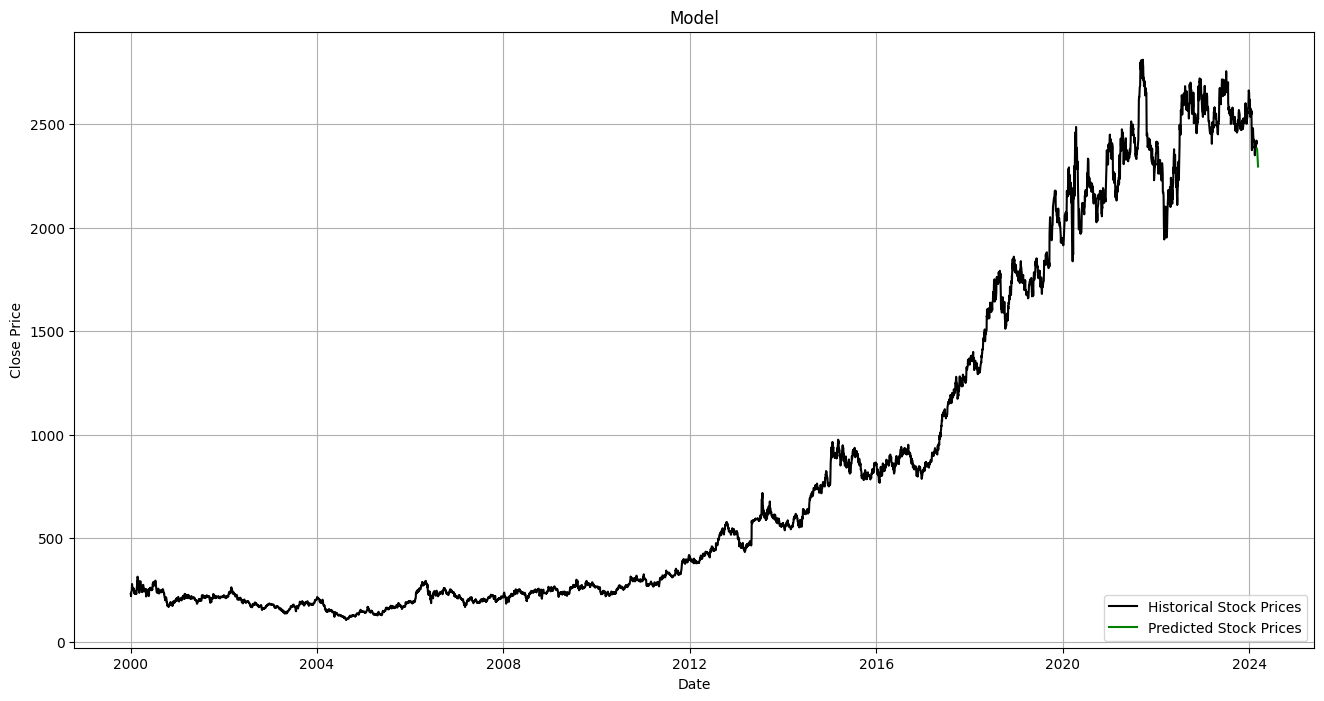

In [11]:
# Predict the stock prices for the next 10 days
num_days_to_predict = 10

# Prepare the input data for prediction
inputs = dataset_scaled[-60:]  # Last 60 days' data
X_test = []

# Generate sequences for prediction
for i in range(num_days_to_predict):
    sequence = inputs[-60:].reshape(1, 60, 1)  # Reshape the sequence to match model input shape
    next_day_prediction = model.predict(sequence)  # Predict the next day
    X_test.append(next_day_prediction)
    inputs = np.append(inputs, next_day_prediction)  # Add the prediction to inputs

# Convert to numpy array
X_test = np.array(X_test)

# Reshape X_test to match the expected shape of model's prediction output
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1]))

# Inverse transform the predicted stock prices
predicted_stock_prices = sc.inverse_transform(X_test)

# Generate dates for the next 10 days
last_date = df['Date'].iloc[-1]
next_dates = pd.date_range(start=last_date, periods=num_days_to_predict + 1)[1:]

# Plot the results
plt.figure(figsize=(16, 8))
plt.title('Model')
plt.xlabel('Date')
plt.ylabel('Close Price')

# Plot historical data
plt.plot(df['Date'], df['Close'], color='black', label='Historical Stock Prices')

# Plot predicted stock prices for the next 5 days
plt.plot(next_dates, predicted_stock_prices, color='green', label='Predicted Stock Prices')

plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [12]:
next_dates

DatetimeIndex(['2024-03-02', '2024-03-03', '2024-03-04', '2024-03-05',
               '2024-03-06', '2024-03-07', '2024-03-08', '2024-03-09',
               '2024-03-10', '2024-03-11'],
              dtype='datetime64[ns]', freq='D')

In [13]:
predicted_stock_prices

array([[2382.443 ],
       [2380.7617],
       [2374.8687],
       [2366.2197],
       [2356.0017],
       [2344.8987],
       [2333.2441],
       [2321.197 ],
       [2308.8542],
       [2296.3064]], dtype=float32)

[*********************100%%**********************]  1 of 1 completed


12/12 [==============================] - 1s 10ms/step


[*********************100%%**********************]  1 of 1 completed


12/12 [==============================] - 1s 10ms/step


[*********************100%%**********************]  1 of 1 completed


12/12 [==============================] - 1s 10ms/step


[*********************100%%**********************]  1 of 1 completed


12/12 [==============================] - 1s 10ms/step


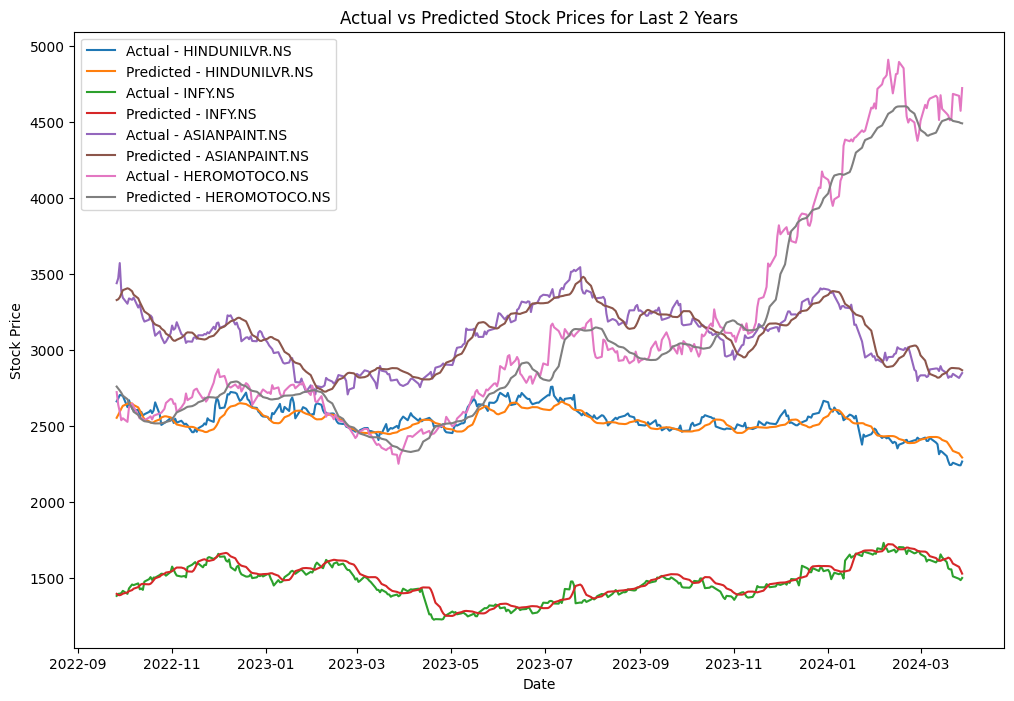

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# Define the list of ticker symbols
ticker_symbols = ['HINDUNILVR.NS', 'INFY.NS', 'ASIANPAINT.NS', 'HEROMOTOCO.NS']

# Set the start and end dates for the historical data
start_date = '2022-04-01'  # Last 2 years
end_date = '2024-04-01'

# Function to train and predict using LSTM model
def train_predict_lstm(ticker_symbol):
    # Fetch historical data from Yahoo Finance
    df = yf.download(ticker_symbol, start=start_date, end=end_date)
    df.reset_index(inplace=True)

    # Preprocessing data
    sc = MinMaxScaler(feature_range=(0, 1))
    dataset_scaled = sc.fit_transform(df['Close'].values.reshape(-1,1))

    # Creating training data
    X_train = []
    y_train = []
    for i in range(60, len(dataset_scaled)):
        X_train.append(dataset_scaled[i-60:i, 0])
        y_train.append(dataset_scaled[i, 0])
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

    # Creating the LSTM model
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))

    # Compiling the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Training the model
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    # Predicting the stock prices
    inputs = dataset_scaled[-len(df):]
    X_test = []
    for i in range(60, len(inputs)):
        X_test.append(inputs[i-60:i, 0])
    X_test = np.array(X_test)
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    predicted_stock_price = model.predict(X_test)
    predicted_stock_price = sc.inverse_transform(predicted_stock_price)

    # Calculating performance metrics
    rmse = sqrt(mean_squared_error(df['Close'][-len(predicted_stock_price):], predicted_stock_price))
    mae = mean_absolute_error(df['Close'][-len(predicted_stock_price):], predicted_stock_price)
    r2 = r2_score(df['Close'][-len(predicted_stock_price):], predicted_stock_price)

    return df['Date'][-len(predicted_stock_price):], df['Close'][-len(predicted_stock_price):], predicted_stock_price, rmse, mae, r2

# Plotting performance for each stock
plt.figure(figsize=(12, 8))

for ticker_symbol in ticker_symbols:
    dates, actual_prices, predicted_prices, rmse, mae, r2 = train_predict_lstm(ticker_symbol)
    plt.plot(dates, actual_prices, label=f'Actual - {ticker_symbol}')
    plt.plot(dates, predicted_prices, label=f'Predicted - {ticker_symbol}')

plt.title('Actual vs Predicted Stock Prices for Last 2 Years')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


[*********************100%%**********************]  1 of 1 completed


1/1 [==============================] - 0s 14ms/step


[*********************100%%**********************]  1 of 1 completed


1/1 [==============================] - 0s 21ms/step


[*********************100%%**********************]  1 of 1 completed


1/1 [==============================] - 0s 14ms/step


[*********************100%%**********************]  1 of 1 completed


1/1 [==============================] - 0s 14ms/step


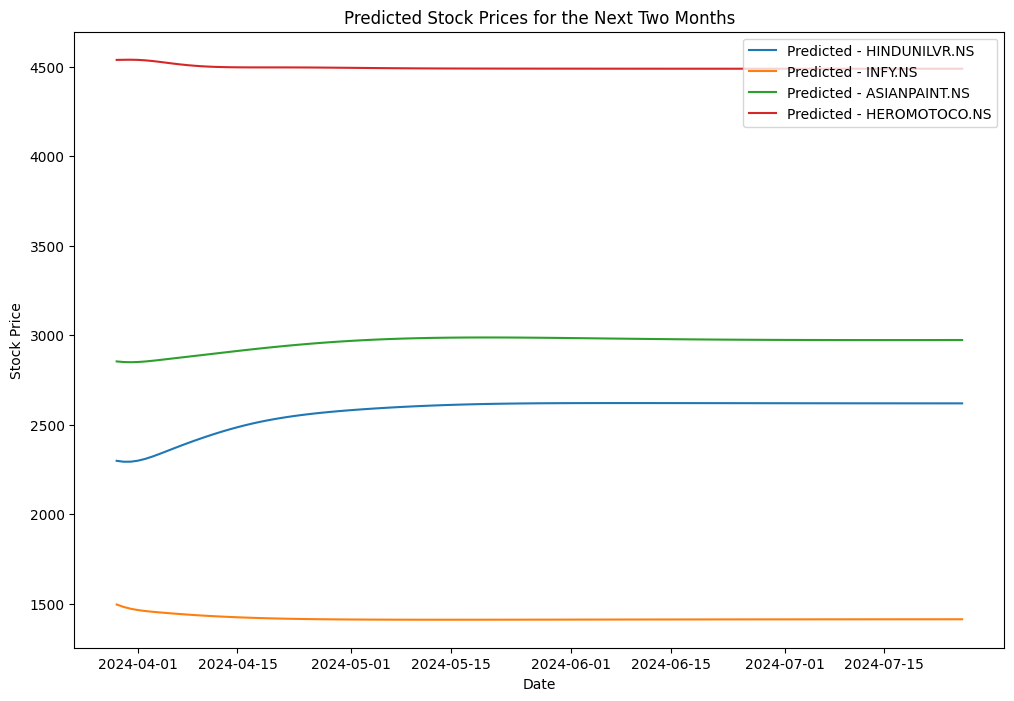

In [20]:
# Function to predict stock prices for the next two months
def predict_future_prices(ticker_symbol):
    # Fetch historical data from Yahoo Finance
    df = yf.download(ticker_symbol, start=start_date, end=end_date)
    df.reset_index(inplace=True)

    # Preprocessing data
    sc = MinMaxScaler(feature_range=(0, 1))
    dataset_scaled = sc.fit_transform(df['Close'].values.reshape(-1,1))

    # Creating training data
    X_train = []
    y_train = []
    for i in range(60, len(dataset_scaled)):
        X_train.append(dataset_scaled[i-60:i, 0])
        y_train.append(dataset_scaled[i, 0])
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

    # Creating the LSTM model
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))

    # Compiling the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Training the model
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    # Predicting the stock prices for the next two months
    last_60_days = dataset_scaled[-60:]
    future_prices = []
    for i in range(60, 60+60*2):  # Predicting for the next two months (60 days each)
        X_test = np.array([last_60_days])
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
        predicted_price = model.predict(X_test)
        future_prices.append(predicted_price[0][0])
        last_60_days = np.append(last_60_days[1:], predicted_price[0][0])
    
    # Inverse scaling to get actual stock prices
    predicted_stock_prices = sc.inverse_transform(np.array(future_prices).reshape(-1, 1))

    # Generating dates for the next two months
    last_date = df['Date'].iloc[-1]
    next_dates = pd.date_range(start=last_date, periods=60*2+1)[1:]  # Exclude the last date

    return next_dates, predicted_stock_prices

# Predicting future prices for each stock
future_predictions = {}
for ticker_symbol in ticker_symbols:
    next_dates, predicted_prices = predict_future_prices(ticker_symbol)
    future_predictions[ticker_symbol] = (next_dates, predicted_prices)

# Plotting predicted prices for the next two months
plt.figure(figsize=(12, 8))
for ticker_symbol, (next_dates, predicted_prices) in future_predictions.items():
    plt.plot(next_dates, predicted_prices, label=f'Predicted - {ticker_symbol}')

plt.title('Predicted Stock Prices for the Next Two Months')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


In [33]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# Define the list of ticker symbols
ticker_symbols = ['HINDUNILVR.NS', 'INFY.NS', 'ASIANPAINT.NS', 'HEROMOTOCO.NS']

# Set the start and end dates for the historical data
start_date = '2024-01-01'  # Last 2 years
end_date = '2024-04-01'

# Function to prepare data with additional features (such as 10-day moving average)
def prepare_data(ticker_symbol):
    # Fetch historical data from Yahoo Finance
    df = yf.download(ticker_symbol, start=start_date, end=end_date)
    df.reset_index(inplace=True)

    # Calculate the 10-day moving average
    df['10MA'] = df['Close'].rolling(window=10).mean()

    # Drop rows with NaN values due to the moving average calculation
    df.dropna(inplace=True)

    # Preprocessing data
    sc = MinMaxScaler(feature_range=(0, 1))
    dataset_scaled = sc.fit_transform(df[['Close', '10MA']])

    # Creating training data
    X_train = []
    y_train = []
    for i in range(60, len(dataset_scaled)):
        X_train.append(dataset_scaled[i-60:i, :])
        y_train.append(dataset_scaled[i, 0])  # Predicting the Close price
    X_train, y_train = np.array(X_train), np.array(y_train)

    return X_train, y_train

# Function to train and predict using LSTM model with additional features
def train_predict_lstm_with_features(ticker_symbol):
    X_train, y_train = prepare_data(ticker_symbol)

    # Creating the LSTM model
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))

    # Compiling the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Training the model
    model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    # Predicting the stock prices
    last_60_days = X_train[-1]  # Use the last 60 days from the training data for prediction
    predicted_prices = []
    for i in range(60):  # Predicting for 60 days
        X_test = np.array([last_60_days])
        predicted_price = model.predict(X_test)[0][0]
        predicted_prices.append(predicted_price)
        # Shift the input by one day and update the moving average
        last_60_days = np.roll(last_60_days, -1, axis=0)
        last_60_days[-1][-1] = predicted_price  # Update the last value with the predicted price

    # Inverse scaling to get actual stock prices
    predicted_stock_prices = sc.inverse_transform(np.array(predicted_prices).reshape(-1, 1))

    # Generating dates for the next 60 days
    last_date = df['Date'].iloc[-1]
    next_dates = pd.date_range(start=last_date, periods=60+1)[1:]  # Exclude the last date

    return next_dates, predicted_stock_prices

# Predicting future prices for each stock
future_predictions = {}
for ticker_symbol in ticker_symbols:
    next_dates, predicted_prices = train_predict_lstm_with_features(ticker_symbol)
    future_predictions[ticker_symbol] = (next_dates, predicted_prices)

# Plotting predicted prices for the next 60 days
plt.figure(figsize=(12, 8))
for ticker_symbol, (next_dates, predicted_prices) in future_predictions.items():
    plt.plot(next_dates, predicted_prices, label=f'Predicted - {ticker_symbol}')

plt.title('Predicted Stock Prices for the Next 60 Days (with 10-day moving average)')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


[*********************100%%**********************]  1 of 1 completed


1/1 [==============================] - 0s 20ms/step


ValueError: non-broadcastable output operand with shape (60,1) doesn't match the broadcast shape (60,2)

[*********************100%%**********************]  1 of 1 completed


Epoch 1/50
12/12 [==============================] - 2s 40ms/step - loss: 0.3088 - val_loss: 0.2926
Epoch 2/50
12/12 [==============================] - 0s 5ms/step - loss: 0.2216 - val_loss: 0.1316
Epoch 3/50
12/12 [==============================] - 0s 5ms/step - loss: 0.1324 - val_loss: 0.0523
Epoch 4/50
12/12 [==============================] - 0s 5ms/step - loss: 0.0959 - val_loss: 0.0362
Epoch 5/50
12/12 [==============================] - 0s 5ms/step - loss: 0.0844 - val_loss: 0.0294
Epoch 6/50
12/12 [==============================] - 0s 5ms/step - loss: 0.0798 - val_loss: 0.0304
Epoch 7/50
12/12 [==============================] - 0s 5ms/step - loss: 0.0784 - val_loss: 0.0293
Epoch 8/50
12/12 [==============================] - 0s 5ms/step - loss: 0.0759 - val_loss: 0.0307
Epoch 9/50
12/12 [==============================] - 0s 5ms/step - loss: 0.0737 - val_loss: 0.0289
Epoch 10/50
12/12 [==============================] - 0s 5ms/step - loss: 0.0739 - val_loss: 0.0299
Epoch 11/50
12/12 

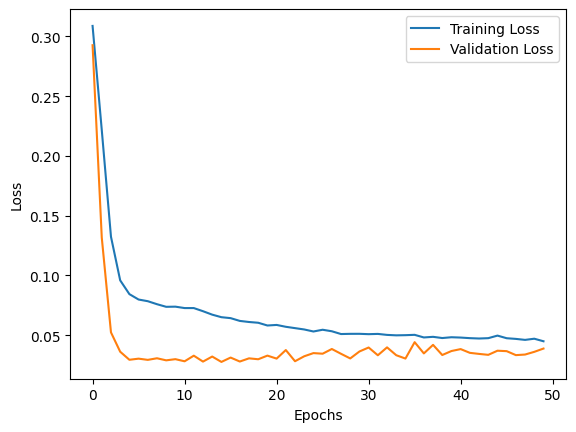

3/3 [==============================] - 0s 2ms/step


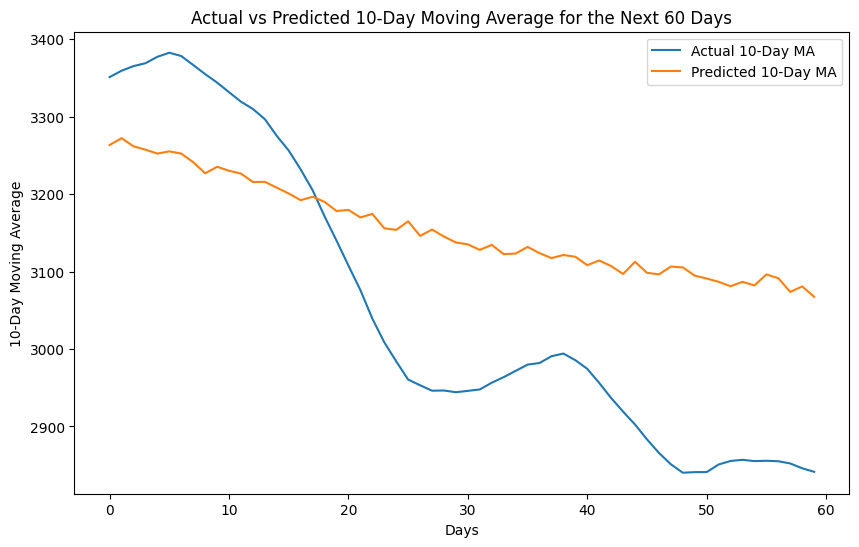

In [38]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# Define the ticker symbol
ticker_symbol = 'ASIANPAINT.NS'

# Set the start and end dates for the historical data
start_date = '2022-01-01'  # Last 2 years
end_date = '2024-04-01'

# Retrieve historical data
data = yf.download(ticker_symbol, start=start_date, end=end_date)

# Compute the 10-day moving average
data['MA10'] = data['Close'].rolling(window=10).mean()

# Drop rows with missing values
data.dropna(inplace=True)

# Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['MA10']])  # Use only the 10-day moving average

# Prepare the data for LSTM
X, y = [], []
for i in range(len(scaled_data) - 10 - 60):  # Adjusted for predicting 60 days ahead
    X.append(scaled_data[i:i+10])
    y.append(scaled_data[i+10:i+10+60])  # Predicting the 10-day moving average for the next 60 days

X, y = np.array(X), np.array(y)

# Split data into training and testing sets (80% train, 20% test)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build LSTM model
model = Sequential([
    LSTM(units=50, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    Dense(60)  # Adjusted for predicting 60 days ahead
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Make predictions for the next 60 days
predictions = model.predict(X_test)

# Inverse transform the predictions and actual values for the 10-day moving average
predictions = scaler.inverse_transform(predictions.reshape(-1, 60))  # Reshape predictions
actual = scaler.inverse_transform(y_test.reshape(-1, 60))  # Reshape actual values

# Plot actual vs predicted values for the next 60 days
plt.figure(figsize=(10, 6))
plt.plot(actual[-1], label='Actual 10-Day MA')
plt.plot(predictions[-1], label='Predicted 10-Day MA')
plt.xlabel('Days')
plt.ylabel('10-Day Moving Average')
plt.title('Actual vs Predicted 10-Day Moving Average for the Next 60 Days')
plt.legend()
plt.show()


In [40]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# Define the ticker symbol
ticker_symbol = 'ASIANPAINT.NS'

# Set the start and end dates for the historical data
start_date = '2022-01-01'  # Last 2 years
end_date = '2024-04-27'  # Up to April 27, 2024

# Retrieve historical data
data = yf.download(ticker_symbol, start=start_date, end=end_date)

# Compute the 10-day moving average
data['MA10'] = data['Close'].rolling(window=10).mean()

# Drop rows with missing values
data.dropna(inplace=True)

# Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['MA10']])  # Use only the 10-day moving average

# Prepare the data for LSTM
X, y = [], []
for i in range(len(scaled_data) - 10 - 60):  # Adjusted for predicting 60 days ahead
    X.append(scaled_data[i:i+10])
    y.append(scaled_data[i+10:i+10+60])  # Predicting the 10-day moving average for the next 60 days

X, y = np.array(X), np.array(y)

# Build LSTM model
model = Sequential([
    LSTM(units=50, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    Dense(60)  # Adjusted for predicting 60 days ahead
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X, y, epochs=50, batch_size=32, verbose=1)

# Make predictions for the future dates
future_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), end='2024-06-27')
scaled_future_dates = scaler.transform(data.iloc[-10:][['MA10']])

future_predictions = []
for i in range(len(future_dates) - 10):
    prediction = model.predict(scaled_future_dates.reshape(1, 10, 1))
    future_predictions.append(prediction.flatten())
    scaled_future_dates = np.append(scaled_future_dates[1:], prediction.reshape(1, -1), axis=0)  # Reshape prediction before appending

# Inverse transform the predicted future 10-day moving averages
predicted_future_10day_ma = scaler.inverse_transform(np.array(future_predictions))

# Plot the predicted future 10-day moving averages
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['MA10'], label='Historical 10-Day MA', color='blue')
plt.plot(future_dates[:len(predicted_future_10day_ma)], predicted_future_10day_ma, label='Predicted Future 10-Day MA', color='red')
plt.xlabel('Date')
plt.ylabel('10-Day Moving Average')
plt.title('Predicted Future 10-Day Moving Average')
plt.legend()
plt.grid(True)
plt.show()


[*********************100%%**********************]  1 of 1 completed


Epoch 1/50
16/16 [==============================] - 1s 4ms/step - loss: 0.2977
Epoch 2/50
16/16 [==============================] - 0s 3ms/step - loss: 0.1753
Epoch 3/50
16/16 [==============================] - 0s 3ms/step - loss: 0.0987
Epoch 4/50
16/16 [==============================] - 0s 6ms/step - loss: 0.0785
Epoch 5/50
16/16 [==============================] - 0s 3ms/step - loss: 0.0713
Epoch 6/50
16/16 [==============================] - 0s 3ms/step - loss: 0.0708
Epoch 7/50
16/16 [==============================] - 0s 3ms/step - loss: 0.0672
Epoch 8/50
16/16 [==============================] - 0s 5ms/step - loss: 0.0674
Epoch 9/50
16/16 [==============================] - 0s 4ms/step - loss: 0.0650
Epoch 10/50
16/16 [==============================] - 0s 3ms/step - loss: 0.0643
Epoch 11/50
16/16 [==============================] - 0s 6ms/step - loss: 0.0625
Epoch 12/50
16/16 [==============================] - 0s 5ms/step - loss: 0.0607
Epoch 13/50
16/16 [==============================

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 1 has size 60

In [41]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# Define the ticker symbol
ticker_symbol = 'ASIANPAINT.NS'

# Set the start and end dates for the historical data
start_date = '2022-01-01'  # Last 2 years
end_date = '2024-04-01'

# Retrieve historical data
data = yf.download(ticker_symbol, start=start_date, end=end_date)

# Compute the 10-day moving average
data['MA10'] = data['Close'].rolling(window=10).mean()

# Drop rows with missing values
data.dropna(inplace=True)

# Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['MA10']])  # Use only the 10-day moving average

# Prepare the data for LSTM
X, y = [], []
for i in range(len(scaled_data) - 10 - 60):  # Adjusted for predicting 60 days ahead
    X.append(scaled_data[i:i+10])
    y.append(scaled_data[i+10:i+10+60])  # Predicting the 10-day moving average for the next 60 days

X, y = np.array(X), np.array(y)

# Build LSTM model
model = Sequential([
    LSTM(units=50, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    Dense(60)  # Adjusted for predicting 60 days ahead
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X, y, epochs=50, batch_size=32, verbose=1)

# Make predictions for the future dates
future_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=60)
scaled_future_dates = scaler.transform(data.iloc[-10:][['MA10']])

future_predictions = []
for i in range(60):
    prediction = model.predict(scaled_future_dates.reshape(1, 10, 1))
    future_predictions.append(prediction.flatten())
    scaled_future_dates = np.append(scaled_future_dates[1:], prediction, axis=0)

# Inverse transform the predicted future 10-day moving averages
predicted_future_10day_ma = scaler.inverse_transform(np.array(future_predictions))

# Plot the predicted trend of the 10-day moving average for the next two months
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['MA10'], label='Historical 10-Day MA', color='blue')
plt.plot(future_dates, predicted_future_10day_ma, label='Predicted Future 10-Day MA', color='red')
plt.xlabel('Date')
plt.ylabel('10-Day Moving Average')
plt.title('Predicted Trend of 10-Day Moving Average for the Next Two Months')
plt.legend()
plt.grid(True)
plt.show()


[*********************100%%**********************]  1 of 1 completed


Epoch 1/50
15/15 [==============================] - 1s 4ms/step - loss: 0.2804
Epoch 2/50
15/15 [==============================] - 0s 3ms/step - loss: 0.1517
Epoch 3/50
15/15 [==============================] - 0s 3ms/step - loss: 0.0919
Epoch 4/50
15/15 [==============================] - 0s 3ms/step - loss: 0.0793
Epoch 5/50
15/15 [==============================] - 0s 3ms/step - loss: 0.0743
Epoch 6/50
15/15 [==============================] - 0s 3ms/step - loss: 0.0708
Epoch 7/50
15/15 [==============================] - 0s 3ms/step - loss: 0.0687
Epoch 8/50
15/15 [==============================] - 0s 3ms/step - loss: 0.0671
Epoch 9/50
15/15 [==============================] - 0s 3ms/step - loss: 0.0672
Epoch 10/50
15/15 [==============================] - 0s 3ms/step - loss: 0.0652
Epoch 11/50
15/15 [==============================] - 0s 3ms/step - loss: 0.0667
Epoch 12/50
15/15 [==============================] - 0s 3ms/step - loss: 0.0636
Epoch 13/50
15/15 [==============================

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 1 has size 60